In [1]:
from smode_import import *
SMODE_data = '/Users/elise/data/SMODE-data/'

uw = xr.open_dataset(SMODE_data+'TSG/'+'IOP2_underway.nc')

#https://docs.google.com/spreadsheets/d/1XVX8U42z-St1C86zHNeipE7-8niuVlo-tI26yRPQCXQ/edit?gid=1610341697#gid=1610341697
#print(df.head())

# growth and grazing rates I can use:
# https://docs.google.com/spreadsheets/d/1rEaZOv1R1icXIXRUVSTje8rvcD_qZpm6Phyj6fLy8YM/edit?gid=1944783679#gid=1944783679

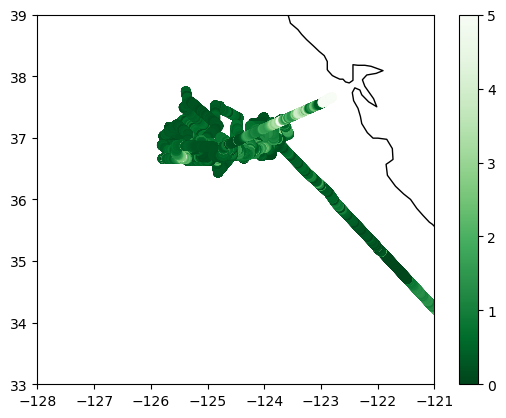

In [2]:
plt.scatter(uw.lon, uw.lat, c=uw.chl, cmap='Greens_r', vmin=0, vmax=5)
coastline(plt.gca())
plt.colorbar()
plt.show();

In [3]:
# Load data
#df = pd.read_excel('../other/growth_grazing_fcm_chla_all_10_17_2024_FINAL.xlsx')
df = pd.read_excel('/Users/elise/data/SMODE-data/biology/growth_grazing_OLD.xlsx')

# Chlorophyll concentrations
#df_chl = pd.read_excel('/Users/elise/data/SMODE-data/biology/smode_chla_supor_converted_4_2024.xlsx')
df_chl = pd.read_excel('/Users/elise/data/SMODE-data/biology/smode_chla_supor_converted_4_2024_with_standard_error_elise.xlsx')
df_chl.columns = df_chl.iloc[0]  # Use the 0th row as column names
df_chl = df_chl[1:]

# Combine into an DataArray

unique_casts = np.unique(np.array(df.Cast))
unique_depths = np.unique(np.array(df.Depth))
surface_replicates = np.array(df.Surface_replicate)
qc_flags = np.array(df.qc_flag)

casts   = []
depths  = []
grazings= []
growths = []
chl     = []
times   = []
lats    = []
lons    = []
expt_ID = []
grazing_se= []
growth_se = []

for cast in unique_casts:
    for depth in unique_depths:

        # Find rows for each cast and depth
        rows = np.where((np.array(df.Cast)==cast) & (np.array(df.Depth)==depth))[0]
        #print(rows)

        # Only keep those with SR=0 and QC=0
        rows = rows[(surface_replicates[rows]==0)]# & (qc_flags[rows]==0)]
        #print(rows)
        #print(np.array(df.grazing_chla)[rows])
        
        # Only keep the first one because they are all the same??
        if len(rows)>=1:
            row = rows[0]
            
            casts.append(np.array(df.Cast)[row])
            depths.append(np.array(df.Depth)[row])
            grazings.append(np.array(df.grazing_chla)[row])            
            growths.append(np.array(df.growth_chla)[row])
            times.append(np.array(df.Time)[row]) 
            lats.append(np.array(df.Lat)[row]) 
            lons.append(np.array(df.Lon)[row])
            expt_ID.append(np.array(df.Expt_ID)[row])
            grazing_se.append(np.array(df.grazing_se)[row])
            growth_se.append(np.array(df.growth_se)[row])

dataset = xr.Dataset(
    {
        'cast':('time', casts),
        'depth':('time', depths),
        'grazing': ('time', grazings),
        'growth': ('time', growths),
        'time': ('time', times),
        'lat': ('time', lats),
        'lon': ('time', lons),
        'expt_ID': ('time', expt_ID),
        'grazing_se': ('time', grazing_se),
        'growth_se': ('time', growth_se),
    },
    attrs={'name': 'Growth and Grazing Rates'},
)
dataset = dataset.sortby('time')
dataset

<xarray.Dataset> Size: 2kB
Dimensions:     (time: 21)
Coordinates:
  * time        (time) datetime64[ns] 168B 2023-04-12T17:09:54 ... 2023-04-24...
Data variables:
    cast        (time) int64 168B 1 1 1 5 5 5 8 8 9 ... 15 15 16 16 17 19 20 20
    depth       (time) float64 168B 5.0 10.0 27.0 5.0 10.0 ... 5.0 5.0 5.0 10.0
    grazing     (time) float64 168B -0.7348 -0.5954 -0.03186 ... -1.114 -0.8734
    growth      (time) float64 168B 0.5845 0.8281 0.3071 ... -0.2815 1.399 1.217
    lat         (time) float64 168B 37.02 37.02 37.02 ... 36.83 36.81 36.81
    lon         (time) float64 168B -123.8 -123.8 -123.8 ... -124.2 -124.2
    expt_ID     (time) <U11 924B 'Dil1C1N21' 'Dil3C1N17' ... 'Dil45C20N20'
    grazing_se  (time) float64 168B 0.1349 0.2867 0.09611 ... 0.1253 0.09824
    growth_se   (time) float64 168B 0.08794 0.1751 0.05883 ... 0.08894 0.06983
Attributes:
    name:     Growth and Grazing Rates

In [4]:
chl_a = []

for i in range(len(dataset.time)):
    row = np.where(
        (np.array(df_chl.Expt_ID)==dataset.isel(time=i).expt_ID.values) & 
        (np.array(df_chl.Cast)==dataset.isel(time=i).cast.values) & 
        (np.array(df_chl.Depth)==dataset.isel(time=i).depth.values) & 
        (np.array(df_chl.dilution_fraction)==1) &
        (np.array(df_chl.Time_point)=='t0')
    )[0]

    
    if len(row)==0: value = [9999.]; 
    else: value = np.array(df_chl.ChlAugL)[row]; 
    chl_a.append(value)
    
    #print(np.array(df_chl.Expt_ID)[idx],np.array(df_chl.Cast)[idx],np.array(df_chl.Depth)[idx])
    
    #plt.axvline(i+1,color='k')
    #plt.plot(np.ones(len(chl_a))*(i+1),chl_a,'or')
    #print(np.array(df_chl.ChlAugL)[idx])
    #print(idx)
dataset['chl_a'] = xr.DataArray(np.float64(np.concatenate(chl_a)), dims='time', 
                                coords={'time':dataset.time.values})
dataset


<xarray.Dataset> Size: 3kB
Dimensions:     (time: 21)
Coordinates:
  * time        (time) datetime64[ns] 168B 2023-04-12T17:09:54 ... 2023-04-24...
Data variables:
    cast        (time) int64 168B 1 1 1 5 5 5 8 8 9 ... 15 15 16 16 17 19 20 20
    depth       (time) float64 168B 5.0 10.0 27.0 5.0 10.0 ... 5.0 5.0 5.0 10.0
    grazing     (time) float64 168B -0.7348 -0.5954 -0.03186 ... -1.114 -0.8734
    growth      (time) float64 168B 0.5845 0.8281 0.3071 ... -0.2815 1.399 1.217
    lat         (time) float64 168B 37.02 37.02 37.02 ... 36.83 36.81 36.81
    lon         (time) float64 168B -123.8 -123.8 -123.8 ... -124.2 -124.2
    expt_ID     (time) <U11 924B 'Dil1C1N21' 'Dil3C1N17' ... 'Dil45C20N20'
    grazing_se  (time) float64 168B 0.1349 0.2867 0.09611 ... 0.1253 0.09824
    growth_se   (time) float64 168B 0.08794 0.1751 0.05883 ... 0.08894 0.06983
    chl_a       (time) float64 168B 1.499 2.082 0.8503 ... 0.9436 1.956 2.548
Attributes:
    name:     Growth and Grazing Rates

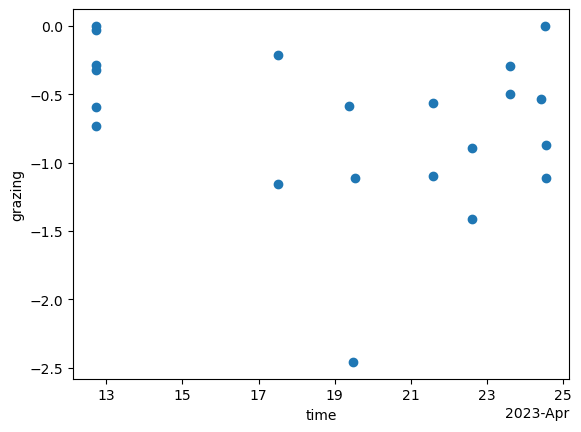

In [5]:
dataset.grazing.plot(marker='o',linestyle='')

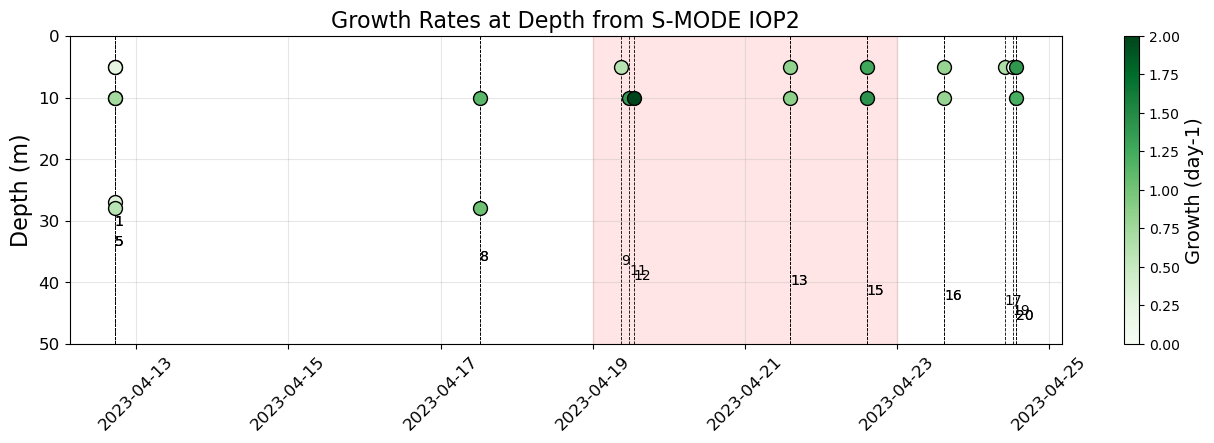

In [19]:
plt.figure(figsize=(16,4))
for i in range(len(dataset.time)):

    data = dataset.isel(time=i)
    
    plt.scatter(data.time, data.depth, s=100, marker='o', edgecolor='k',
                c=data.growth, vmin=0, vmax=2, cmap='Greens', zorder=101)
    plt.axvline(pd.Timestamp(str(data.time.values)),linestyle='--',color='k',linewidth=0.6)
    plt.text(data.time,30+data.cast.values*0.8,str(data.cast.values))
    
cbar=plt.colorbar()
cbar.set_label('Growth (day-1)',fontsize=14)

# Fill between submesoscale eddy times
plt.fill_between([pd.Timestamp('2023-04-19'),pd.Timestamp('2023-04-23')],[120],alpha=0.1,color='r')

plt.ylim(0,50)
plt.gca().invert_yaxis()
plt.xticks(rotation=0,fontsize=12)
plt.yticks(fontsize=12)
plt.ylabel('Depth (m)',fontsize=16)
plt.xlabel('')
plt.grid(alpha=0.3)
plt.xticks(rotation=45)#np.arange(23))
plt.title(r'Growth Rates at Depth from S-MODE IOP2',fontsize=16)
#plt.xlim(pd.Timestamp('2023-04-18'),pd.Timestamp('2023-04-25'))
plt.show()

In [56]:
ds_interpolated = xr.open_dataset('eddy_core_position.nc')

ds_interpolated_on_grazing = ds_interpolated.interp(time=dataset.time,
                                                        method='quadratic',
                                                        kwargs={"fill_value": "extrapolate"})

# find distance in latitude and longitude for each time step
dlat = ds_interpolated_on_grazing.lat - dataset.lat
dlon = ds_interpolated_on_grazing.lon - dataset.lon

# convert distance into km
dy_km = dlat * 111320 / 1e3
dx_km = dlon * (111320 * np.cos(np.radians(ds_interpolated_on_grazing.lat.values))) / 1e3
dist_from_core = np.sqrt(dx_km**2 + dy_km**2)

dataset['dist_from_core'] = xr.DataArray(dist_from_core.values, dims='time', 
                                coords={'time':dataset.time.values})
dataset

<xarray.Dataset> Size: 3kB
Dimensions:         (time: 21)
Coordinates:
  * time            (time) datetime64[ns] 168B 2023-04-12T17:09:54 ... 2023-0...
Data variables:
    cast            (time) int64 168B 1 1 1 5 5 5 8 8 ... 15 16 16 17 19 20 20
    depth           (time) float64 168B 5.0 10.0 27.0 5.0 ... 5.0 5.0 5.0 10.0
    grazing         (time) float64 168B -0.7348 -0.5954 ... -1.114 -0.8734
    growth          (time) float64 168B 0.5845 0.8281 0.3071 ... 1.399 1.217
    lat             (time) float64 168B 37.02 37.02 37.02 ... 36.83 36.81 36.81
    lon             (time) float64 168B -123.8 -123.8 -123.8 ... -124.2 -124.2
    expt_ID         (time) <U11 924B 'Dil1C1N21' 'Dil3C1N17' ... 'Dil45C20N20'
    grazing_se      (time) float64 168B 0.1349 0.2867 0.09611 ... 0.1253 0.09824
    growth_se       (time) float64 168B 0.08794 0.1751 ... 0.08894 0.06983
    chl_a           (time) float64 168B 1.499 2.082 0.8503 ... 1.956 2.548
    dist_from_core  (time) float64 168B 221.0 221.0 221.0 ... 41.51 41.59 41.59
Attributes:
    name:     Growth and Grazing Rates

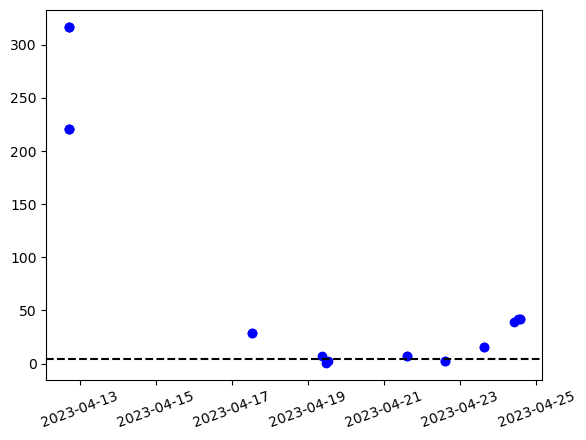

In [60]:
plt.plot(dataset.time, dataset.dist_from_core, 'ob')
plt.axhline(4,linestyle='--',color='k')
plt.xticks(rotation=20);

In [39]:
#dataset.growth.plot.hist(edgecolor='w',facecolor='lightgreen')
#(-dataset.grazing).plot.hist(edgecolor='w',facecolor='orange')
#plt.show();

#plt.scatter(dataset.time, -dataset.depth, c=dataset.grazing, cmap='Greens')

(-2.45815443278307, 0.1)

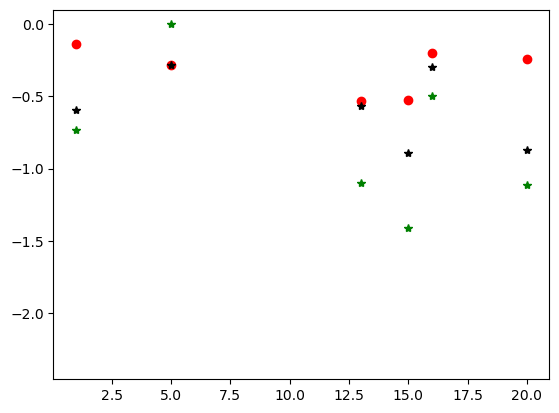

In [25]:
for cast in np.unique(dataset.cast):
    data = dataset.isel(time=(dataset['cast']==cast))

    if (5 in data.depth) & (10 in data.depth):
        delta_grazing = data.isel(time=(data['depth']==5)).grazing - data.isel(time=(data['depth']==10)).grazing
        plt.plot(cast,np.abs(delta_grazing.values)*-1,'or')
        plt.plot(cast,data.isel(time=(data['depth']==5)).grazing,'*g')
        plt.plot(cast,data.isel(time=(data['depth']==10)).grazing,'*k')
        
plt.ylim(dataset.grazing.min(),0.1)


(-127.0, -121.0)

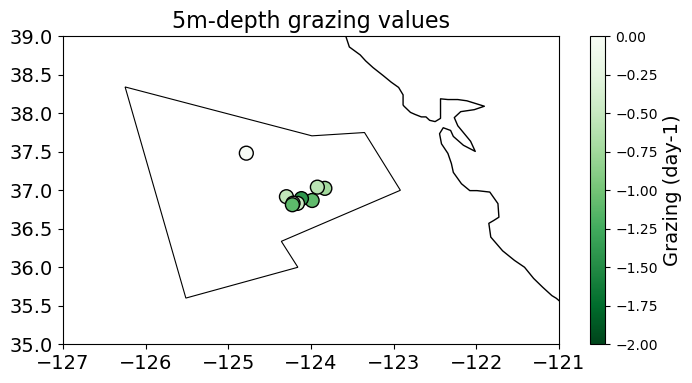

In [22]:
plt.figure(figsize=(8,4))

data_at_depth_5 = dataset.where(dataset.depth == 5, drop=True)

plt.scatter(data_at_depth_5.lon, data_at_depth_5.lat, c=data_at_depth_5.grazing,
            s=100, vmin=-2, vmax=0, cmap='Greens_r', edgecolor='k')
cbar=plt.colorbar()
cbar.set_label('Grazing (day-1)',fontsize=14)
plt.title('5m-depth grazing values',fontsize=16)
plt.xticks(fontsize=14); plt.yticks(fontsize=14); 
smode_pgon(plt.gca())
coastline(plt.gca())
plt.ylim(35,39); plt.xlim(-127,-121)

In [61]:
dataset.to_netcdf('biology_data.nc',mode='w')

In [48]:
dataset#.time.plot(x='time',linestyle='-',marker='o')

<xarray.Dataset> Size: 3kB
Dimensions:     (time: 21)
Coordinates:
  * time        (time) datetime64[ns] 168B 2023-04-12T17:09:54 ... 2023-04-24...
Data variables:
    cast        (time) int64 168B 1 1 1 5 5 5 8 8 9 ... 15 15 16 16 17 19 20 20
    depth       (time) float64 168B 5.0 10.0 27.0 5.0 10.0 ... 5.0 5.0 5.0 10.0
    grazing     (time) float64 168B -0.7348 -0.5954 -0.03186 ... -1.114 -0.8734
    growth      (time) float64 168B 0.5845 0.8281 0.3071 ... -0.2815 1.399 1.217
    lat         (time) float64 168B 37.02 37.02 37.02 ... 36.83 36.81 36.81
    lon         (time) float64 168B -123.8 -123.8 -123.8 ... -124.2 -124.2
    expt_ID     (time) <U11 924B 'Dil1C1N21' 'Dil3C1N17' ... 'Dil45C20N20'
    grazing_se  (time) float64 168B 0.1349 0.2867 0.09611 ... 0.1253 0.09824
    growth_se   (time) float64 168B 0.08794 0.1751 0.05883 ... 0.08894 0.06983
    chl_a       (time) float64 168B 1.499 2.082 0.8503 ... 0.9436 1.956 2.548
Attributes:
    name:     Growth and Grazing Rates

In [467]:
for i in range(len(dataset.time)):
    dataset.isel(time=i)

### Casts dates

In [80]:
cast_files = sorted(glob('/Users/elise/data/SMODE-data/CTD/S_MODE_IOP2_SRIDE23_CTD*.nc'))

for file in cast_files:
    cast = xr.open_dataset(file)
    print(file[-5:-3],f'{str(cast.time.values)[2:18]}')

01 2023-04-11T12:57
02 2023-04-11T18:35
03 2023-04-12T00:08
04 2023-04-12T06:17
05 2023-04-12T17:09
06 2023-04-12T23:13
07 2023-04-13T19:45
08 2023-04-17T12:37
09 2023-04-19T08:42
10 2023-04-19T10:36
11 2023-04-19T11:38
12 2023-04-19T13:01
13 2023-04-21T14:23
14 2023-04-22T03:22
15 2023-04-22T14:18
16 2023-04-23T14:55
17 2023-04-24T09:50
18 2023-04-24T11:19
19 2023-04-24T12:28
20 2023-04-24T13:30
21 2023-04-24T14:40
22 2023-04-25T19:32
23 2023-04-26T05:45
24 2023-04-26T14:12
25 2023-04-27T08:59
26 2023-04-27T17:05
27 2023-04-28T12:28
28 2023-05-01T05:14
29 2023-05-01T06:32
30 2023-05-01T07:27
31 2023-05-01T08:20
32 2023-05-01T09:09
33 2023-05-01T09:56


In [64]:
cast_files

[]

## Old stuff

/Users/elise/Desktop/bio-casts/cast_01.nc 2023-04-11 12:57:01+00:00 [37.025] [-123.8335]
/Users/elise/Desktop/bio-casts/cast_05.nc 2023-04-11 18:35:08+00:00 [37.32866667] [-124.00583333]
/Users/elise/Desktop/bio-casts/cast_08.nc 2023-04-12 00:08:11+00:00 [36.71366667] [-124.5675]
/Users/elise/Desktop/bio-casts/cast_09.nc 2023-04-12 06:17:31+00:00 [36.78216667] [-124.87416667]
/Users/elise/Desktop/bio-casts/cast_11.nc 2023-04-12 17:09:54+00:00 [37.482] [-124.7835]
/Users/elise/Desktop/bio-casts/cast_12.nc 2023-04-12 23:13:01+00:00 [37.159] [-124.88133333]
/Users/elise/Desktop/bio-casts/cast_15.nc 2023-04-13 19:45:56+00:00 [37.00466667] [-125.27166667]
/Users/elise/Desktop/bio-casts/cast_16.nc 2023-04-17 12:37:57+00:00 [37.1175] [-123.79133333]
/Users/elise/Desktop/bio-casts/cast_17.nc 2023-04-19 08:42:02+00:00 [37.04066667] [-123.92416667]
/Users/elise/Desktop/bio-casts/cast_19.nc 2023-04-19 10:36:14+00:00 [37.00066667] [-123.92516667]
/Users/elise/Desktop/bio-casts/cast_20.nc 2023-04-1

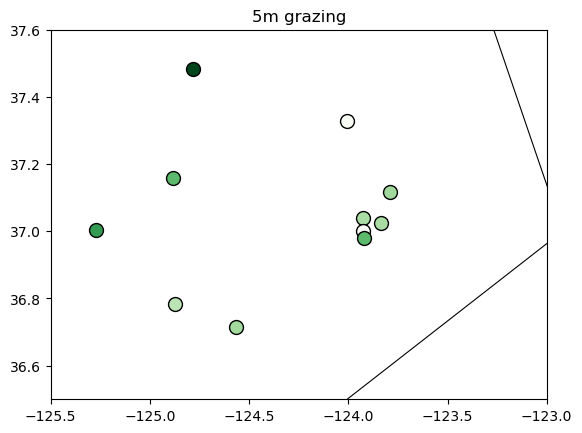

In [61]:
files = sorted(glob('/Users/elise/Desktop/bio-casts/*.nc'))
plt.figure()
for file in files:
    cast = xr.open_dataset(file)
    unix_time = cast.time
    time = datetime.fromtimestamp(int(unix_time), tz=UTC)
    print(file, time, cast.lat.values, cast.lon.values)
    plt.scatter(cast.lon, cast.lat, c=cast.grazing[0], vmin=-2, vmax=0, cmap='Greens_r', 
                edgecolor='k',s=100)
coastline(plt.gca())
smode_pgon(plt.gca())
plt.xlim(-125.5, -123)
plt.ylim(36.5,37.6)
plt.title('5m grazing')
plt.show();

37.00066666666667 -123.92516666666667


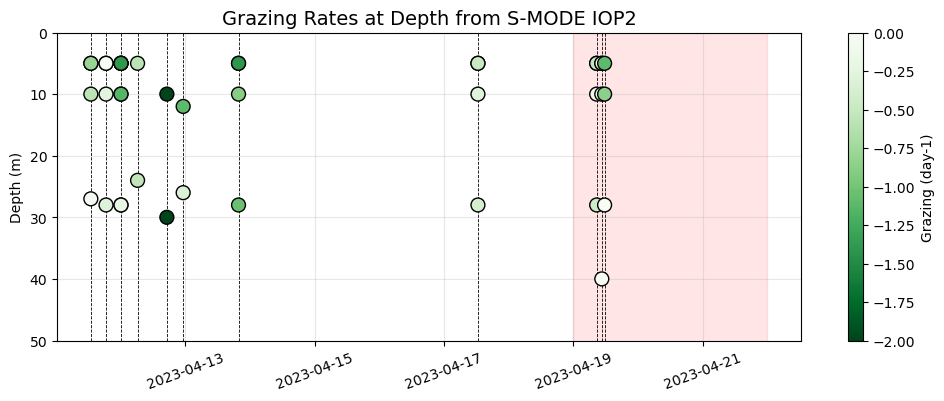

In [415]:
files = sorted(glob('/Users/elise/Desktop/bio-casts/*.nc'))
               
plt.figure(figsize=(12,4))
for file in files:
    cast = xr.open_dataset(file)
    idx=np.where(~np.isnan(cast.grazing))[0]
    unix_time = cast.time
    time = datetime.fromtimestamp(int(unix_time), tz=UTC)
    #plt.plot(np.tile(cast.time,(1,len(idx)),cast.depth[idx])

    #plt.scatter(cast.cast[idx], cast.depth[idx], s=100, marker='o', edgecolor='k',
    #            c=cast.grazing[idx], vmin=-2, vmax=0, cmap='Greens_r',zorder=101)
    plt.scatter(np.tile(time,(1,len(idx))), cast.depth[idx], s=100, marker='o', edgecolor='k',
                c=cast.grazing[idx], vmin=-2, vmax=0, cmap='Greens_r',zorder=101)
    plt.axvline(pd.Timestamp(time),linestyle='--',color='k',linewidth=0.6)
    if int(file[-5:-3])==19: print(cast.lat.values[0], cast.lon.values[0])
cbar=plt.colorbar()
cbar.set_label('Grazing (day-1)')

# Fill between submesoscale eddy times
plt.fill_between([pd.Timestamp('2023-04-19'),pd.Timestamp('2023-04-22')],[120],alpha=0.1,color='r')

plt.ylim(0,50)
plt.gca().invert_yaxis()
plt.xticks(rotation=20)
plt.ylabel('Depth (m)')
plt.xlabel('')
plt.grid(alpha=0.3)
#plt.xticks(np.arange(23))
plt.title(r'Grazing Rates at Depth from S-MODE IOP2',fontsize=14)
#plt.xlim(pd.Timestamp('2023-04-18'),pd.Timestamp('2023-04-25'))
plt.show()


In [77]:
files = sorted(glob('/Users/elise/data/SMODE-data/CTD/S_MODE_IOP2_SRIDE23_CTD*.nc'))
for file in files:
    ctd = xr.open_dataset(file)
    print(f'Cast #{file[-5:-3]}, {str(ctd.time.values)}, lon={ctd.longitude.values}, lat={ctd.latitude.values}')

Cast #01, ['2023-04-11T12:57:01.000002048'], lon=[-123.8335], lat=[37.025]
Cast #02, ['2023-04-11T18:35:08.999996928'], lon=[-124.00583333], lat=[37.32866667]
Cast #03, ['2023-04-12T00:08:11.000002048'], lon=[-124.5675], lat=[36.71366667]
Cast #04, ['2023-04-12T06:17:31.000002560'], lon=[-124.87416667], lat=[36.78216667]
Cast #05, ['2023-04-12T17:09:54.000000000'], lon=[-124.7835], lat=[37.482]
Cast #06, ['2023-04-12T23:13:01.000001536'], lon=[-124.88133333], lat=[37.159]
Cast #07, ['2023-04-13T19:45:56.999999488'], lon=[-125.27166667], lat=[37.00466667]
Cast #08, ['2023-04-17T12:37:57.000001024'], lon=[-123.79133333], lat=[37.1175]
Cast #09, ['2023-04-19T08:42:02.999997952'], lon=[-123.92416667], lat=[37.04066667]
Cast #10, ['2023-04-19T10:36:14.999997952'], lon=[-123.92516667], lat=[37.00066667]
Cast #11, ['2023-04-19T11:38:29.000002048'], lon=[-123.92266667], lat=[36.9795]
Cast #12, ['2023-04-19T13:01:11.999998464'], lon=[-123.92433333], lat=[36.9605]
Cast #13, ['2023-04-21T14:23:13

In [135]:
### Manually enter data

cast8 = {
    'Cast': 8,
    'Exp':'?',
    'Time': pd.Timestamp('2023-04-17T12:33:00'),
    'Depth': 5,
    'Lon': -123.791333333333,
    'Lat': 37.1175000000000,
    'Grazing':-0.747755650361662,
    'Growth':1.31924166856024
         }

cast9 = {
    'Cast': 9,
    'Exp':'?',
    'Time': pd.Timestamp('2023-04-19T08:36:00'),
    'Depth': 5,
    'Lon': -123.924166666667,
    'Lat': 37.0406666666667,
    'Grazing':-0.585022723741871,
    'Growth':0.608625919101716
         }

cast13 = {
    'Cast': 13,
    'Exp':'?',
    'Time': pd.Timestamp('2023-04-21T14:39:00'),
    'Depth': 5,
    'Lon': -123.987500000000,
    'Lat': 36.8673333333333,
    'Grazing':-0.905686169967102,
    'Growth':1.13906638169773
         }
cast15 = {
    'Cast': 15,
    'Exp':'?',
    'Time': pd.Timestamp('2023-04-22T14:16:00'),
    'Depth': 5,
    'Lon': -124.117000000000,
    'Lat': 36.8918333333333,
    'Grazing':-1.36596279890978,
    'Growth':0.945063506752113
         }
cast16 = {
    'Cast': 16,
    'Exp':'?',
    'Time': pd.Timestamp('2023-04-23T14:53:00'),
    'Depth': 5,
    'Lon': -124.164333333333,
    'Lat': 36.8296666666667,
    'Grazing':-0.751961260512232,
    'Growth':0.432844889585135
         }

cast19 = {
    'Cast': 19,
    'Exp':'Dil40C19N24',
    'Time': pd.Timestamp('2023-04-24T12:28:59'),
    'Depth': 5,
    'Lon': -124.2185,
    'Lat': 36.832,
    'Grazing':0,
    'Growth':-0.281457253327985
         }

cast20 = {
    'Cast': 20,
    'Exp':'Dil44C20N24',
    'Time': pd.Timestamp('2023-04-24T13:30:57'),
    'Depth': 5,
    'Lon':-124.2263,
    'Lat': 36.8122,
    'Grazing':-1.11412986041631,
    'Growth':1.39863078667455
         }

cast24 = {
    'Cast': 24,
    'Exp':'Dil48C22N24',
    'Time': pd.Timestamp('2023-04-26T14:12:07'),
    'Depth': 5,
    'Lon': -124.5795,
    'Lat': 36.183,
    'Grazing':np.nan,
    'Growth':0.112757987969503
         }

cast26 = {
    'Cast': 26,
    'Exp':'Dil52C26N24',
    'Time': pd.Timestamp('2023-04-27T17:05:55'),
    'Depth': 5,
    'Lon': -124.7693,
    'Lat': 36.7625,
    'Grazing':-2.13889706883324,
    'Growth':1.6068814247891
         }

casts = [cast8, cast9, cast13, cast15, cast16, cast19, cast20, cast24, cast26]
df = pd.DataFrame(casts)

ds_casts = xr.Dataset(
    {
        'Lat': ('Cast', df['Lat'].values),
        'Lon': ('Cast', df['Lon'].values),
        'Time': ('Cast', pd.to_datetime(df['Time'].values)),
        'Depth': ('Cast', df['Depth'].values),
        'Grazing': ('Cast', df['Grazing'].values),
        'Growth': ('Cast', df['Growth'].values),
    },
    coords={'Cast': df['Cast'].values}  # Use Cast as the coordinate
)

#ds_casts.to_netcdf('grazing_casts.nc',mode='w')
ds_casts

<xarray.Dataset> Size: 504B
Dimensions:  (Cast: 9)
Coordinates:
  * Cast     (Cast) int64 72B 8 9 13 15 16 19 20 24 26
Data variables:
    Lat      (Cast) float64 72B 37.12 37.04 36.87 36.89 ... 36.81 36.18 36.76
    Lon      (Cast) float64 72B -123.8 -123.9 -124.0 ... -124.2 -124.6 -124.8
    Time     (Cast) datetime64[ns] 72B 2023-04-17T12:33:00 ... 2023-04-27T17:...
    Depth    (Cast) int64 72B 5 5 5 5 5 5 5 5 5
    Grazing  (Cast) float64 72B -0.7478 -0.585 -0.9057 ... -1.114 nan -2.139
    Growth   (Cast) float64 72B 1.319 0.6086 1.139 0.9451 ... 1.399 0.1128 1.607

# old

In [ ]:
## 
# Grazing distance from core
from datetime import timezone
import warnings
warnings.filterwarnings("ignore")

grazing_files = sorted(glob('/Users/elise/Desktop/bio-casts/*.nc'))

# Initialize empty arrays
grazing_values = []
dist_from_core_grazing = []

plt.figure()
for file in grazing_files:
    cast = xr.open_dataset(file).isel(depth=0)
    cast_datetime = np.datetime64(datetime.fromtimestamp(int(cast.time), tz=timezone.utc), 'ns')
    # interpolate eddy core position onto grazing timestamp
    ds_interpolated_on_grazing = ds_interpolated.interp(time=cast_datetime, method='quadratic', kwargs={"fill_value": "extrapolate"})
    
    if (~np.isnan(ds_interpolated_on_grazing.lat)) & (cast.depth<8):
        # find distance in latitude and longitude for each time step
        dlat = cast.lat[0].values - ds_interpolated_on_grazing.lat.values
        dlon = cast.lon[0].values - ds_interpolated_on_grazing.lon.values
        
        # convert distance into km
        dy_km = dlat * 111320 / 1e3
        dx_km = dlon * (111320 * np.cos(np.radians(ds_interpolated_on_grazing.lat.values))) / 1e3
        
        # fill arrays
        grazing_values.append(cast.grazing.values)
        dist_from_core_grazing.append(np.sqrt(dx_km**2 + dy_km**2))
        
        #print(f'{cast.depth.values} m depth, {np.round(dist_from_core_grazing,2)} km from eddy core')

        # plot grazing over eddy
        
        p=plt.scatter(dx_km, dy_km,c=cast.grazing.values, cmap='Greens_r', vmin=-1, vmax=1, s=200, alpha=0.5)

# plot eddy composite
plt.contourf(x_eddy - x_eddy.mean() , y_eddy - y_eddy.mean(),eddy_composite,
                 np.linspace(vmin,vmax,30),cmap='RdBu_r',extend='both')
plt.xlim(-8,8)
plt.ylim(-8,8)

# save grazing arrays
grazing_values = np.array(grazing_values)
dist_from_core_grazing = np.array(dist_from_core_grazing)


In [71]:
cast_files = sorted(glob('/Users/elise/data/SMODE-data/CTD/*.nc'))
if len(cast_files)==0: print('oh no')

for cast_file in cast_files:
    cast = xr.open_dataset(cast_file)

    print(f'Cast #{cast_file[-5:-3]}, time = {str(cast.time.values)[2:18]}, Lat = {cast.latitude.values}, Lon = {cast.longitude.values}')

Cast #01, time = 2023-04-11T12:57, Lat = [37.025], Lon = [-123.8335]
Cast #02, time = 2023-04-11T18:35, Lat = [37.32866667], Lon = [-124.00583333]
Cast #03, time = 2023-04-12T00:08, Lat = [36.71366667], Lon = [-124.5675]
Cast #04, time = 2023-04-12T06:17, Lat = [36.78216667], Lon = [-124.87416667]
Cast #05, time = 2023-04-12T17:09, Lat = [37.482], Lon = [-124.7835]
Cast #06, time = 2023-04-12T23:13, Lat = [37.159], Lon = [-124.88133333]
Cast #07, time = 2023-04-13T19:45, Lat = [37.00466667], Lon = [-125.27166667]
Cast #08, time = 2023-04-17T12:37, Lat = [37.1175], Lon = [-123.79133333]
Cast #09, time = 2023-04-19T08:42, Lat = [37.04066667], Lon = [-123.92416667]
Cast #10, time = 2023-04-19T10:36, Lat = [37.00066667], Lon = [-123.92516667]
Cast #11, time = 2023-04-19T11:38, Lat = [36.9795], Lon = [-123.92266667]
Cast #12, time = 2023-04-19T13:01, Lat = [36.9605], Lon = [-123.92433333]
Cast #13, time = 2023-04-21T14:23, Lat = [36.86733333], Lon = [-123.9875]
Cast #14, time = 2023-04-22T0

In [43]:
cast_file[-5:-3]

'33'